In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
from scipy.stats import bootstrap
from  statsmodels.stats import proportion
# Import Machine Scientist ODEint
from importlib.machinery import SourceFileLoader
import pickle
import pysindy as ps
from copy import deepcopy
from scipy.optimize import curve_fit
path = '/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/mcmc_ode.py'
ms_ode = SourceFileLoader('ms_ode', path).load_module()

# Import Machine Scientist (fit)
path = '/export/home/oriolca/BMS_ODE/Lotka_Volterra/rguimera-machine-scientist/machinescientist_fit.py'
ms_fit = SourceFileLoader('ms_fit', path).load_module()

import traceback

In [10]:
#INTEGRATOR ODE
def ode(y,model_x,model_y):
    #k1
    input_x=pd.DataFrame(data=[y],columns=['x','y'])
    input_y=pd.DataFrame(data=[y[::-1]],columns=['x','y'])
    k1 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k2
    input_x=pd.DataFrame(data=[y+k1/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k1/2.)[::-1]],columns=['x','y'])
    k2 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k3
    input_x=pd.DataFrame(data=[y+k2/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k2/2.)[::-1]],columns=['x','y'])
    k3 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k4
    input_x=pd.DataFrame(data=[y+k3],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k3)[::-1]],columns=['x','y'])
    k4 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK45(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]

#def initial_values(x,x0):
#    sol=RK45()
##################################################################################
#INTEGRATOR FIT
def ode_fit(y,model_x,model_y):
    #k1
    input_x=pd.DataFrame(data=[y],columns=['x','y'])
    input_y=pd.DataFrame(data=[y],columns=['x','y'])
    k1 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k2
    input_x=pd.DataFrame(data=[y+k1/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k1/2.)],columns=['x','y'])
    k2 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k3
    input_x=pd.DataFrame(data=[y+k2/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k2/2.)],columns=['x','y'])
    k3 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k4
    input_x=pd.DataFrame(data=[y+k3],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k3)],columns=['x','y'])
    k4 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK45_fit(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode_fit([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]
def func(x,x0,y0):
    sol=RK45_fit([x0,y0],h,t_eval,model_to_fit_x,model_to_fit_y)
    return np.concatenate(sol)

In [11]:
# True solution
import scipy
def dx_LV(x,y):
    return x*(0.1-0.02*y)
def dy_LV(x,y):
    #return a*x*(1.-b*x)
    return y*(0.02*x-0.4)



h=0.5
t= np.arange(0,80,h)
#sol=Euler(ode,y0=[10.,5.], h=h ,t_eval=t)
#print(sol)
def ode_true(t,y):
    return [dx_LV(*y),dy_LV(*y)]
sol=scipy.integrate.solve_ivp(ode_true, [t[0],t[-1]], y0=[10.,5.], method='RK45', t_eval=t)
print(sol)
t_x=sol.y[0]
t_y=sol.y[1]

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.000e-01 ...  7.900e+01  7.950e+01]
        y: [[ 1.000e+01  1.002e+01 ...  1.887e+01  1.963e+01]
            [ 5.000e+00  4.525e+00 ...  1.090e+00  1.082e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 164
     njev: 0
      nlu: 0


In [16]:
#files=[f for f in os.listdir('noise_data/')]
#print(files)
def get_nonzero_terms(model):
    nonzero_indices = np.nonzero(model.coefficients())[1]  # Get indices of non-zero terms
    term_names = model.get_feature_names()  # Get feature names
    nonzero_terms = [term_names[i] for i in nonzero_indices]
    return nonzero_terms

def check_sindy_model(model):
    nonzero_terms=get_nonzero_terms(model)
    if nonzero_terms == ['x','xy','y','xy'] or nonzero_terms == ['x','x y','y','x y']:
        return True
    else:
        return False
def check_sindy_model_mod(model):
    c1=model.coefficients()[0]
    c2=model.coefficients()[1]
    th=0.05
    print(c1[0]-.1,c1[4]+0.02,c2[1]+0.4,c2[4]-0.02)
    """
    if np.abs(c1[0])<th and np.abs(c1[1]-0.1)<0.05 and np.abs(c1[2])<th and np.abs(c1[3])<th and np.abs(c1[4]+0.02)<0.01 and\
    np.abs(c2[0])<th and np.abs(c2[1])<th and np.abs(c2[2]+0.4)<0.1 and np.abs(c2[3])<th and np.abs(c2[4]-0.02)<0.01 and\
    np.abs(c1[5])<th and np.abs(c1[6])<th and np.abs(c1[7])<th and np.abs(c1[8])<th and np.abs(c1[9])<th and np.abs(c1[10])<th and\
    np.abs(c1[11])<th and np.abs(c1[12])<th and np.abs(c1[13])<th and np.abs(c1[14])<th and\
    np.abs(c2[5])<th and np.abs(c2[6])<th and np.abs(c2[7])<th and np.abs(c2[8])<th and np.abs(c2[9])<th and np.abs(c2[10])<th and\
    np.abs(c2[11])<th and np.abs(c2[12])<th and np.abs(c2[13])<th and np.abs(c2[14])<th:
    """
    if np.abs(c1[0]-.1)<th and np.abs(c1[1])<th and np.abs(c1[2])<th and np.abs(c1[3])<th and np.abs(c1[4]+0.02)<th and\
    np.abs(c1[5])<th and \
    np.abs(c2[0])<th and np.abs(c2[1]+0.4)<th and np.abs(c2[2])<th and np.abs(c2[3])<th and np.abs(c2[4]-0.02)<th and\
    np.abs(c2[5])<th:
        return True
    else:
        return False

def err(a,b):
    return np.mean(np.abs(np.subtract(a,b)))

error_treshhold=1.5
    
sigmas=[0.1,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0]
error_sampling_bms=[]
error_sampling_fit=[]
error_sampling_smooth=[]
error_sampling_sindy=[]
error_sampling_sindymod=[]
error_sampling_bms_err=[]
error_sampling_fit_err=[]
error_sampling_smooth_err=[]
error_sampling_sindy_err=[]
error_sampling_sindymod_err=[]
error_sampling_bms_bern_err=[[],[]]
error_sampling_fit_bern_err=[[],[]]
error_sampling_smooth_bern_err=[[],[]]
error_sampling_sindy_bern_err=[[],[]]
error_sampling_sindymod_bern_err=[[],[]]
for sigma in sigmas:
    print('#'*20)
    print(sigma)
    true_bms=[]
    true_fit=[]
    true_smooth=[]
    true_sindy=[]
    true_sindymod=[]
    count=0
    for i in range(0,40):#[34,38,39]:
        file=f'{sigma}_{i}.pkl'
        data=pd.read_csv(f'noise_data/{sigma}_{i}.csv')
        """
        fig1,ax1=plt.subplots()
        ax1.plot(data.t.to_numpy(),data['x'].to_numpy(),'k-',label='data x')
        ax1.plot(data.t.to_numpy(),data['y'].to_numpy(),'k.')#,label='data y'
        ax1.plot(data.t.to_numpy(),t_x,'y-',label='true x')
        ax1.plot(data.t.to_numpy(),t_y,'y.')#,label='true y'
        fig2,ax2=plt.subplots()
        ax2.plot(data.x.to_numpy(),dx_LV(data.x.to_numpy(),data.y.to_numpy()),'y-',label='true x')
        ax2.plot(data.y.to_numpy(),dy_LV(data.x.to_numpy(),data.y.to_numpy()),'y.')#,label='true y'
        """
        #BMS
        try:
            try:
                with open(f'./results/exh_ode_mdl{file[:-4]}.pkl', 'rb') as f:
                    # A new file will be created
                    bms=pd.read_pickle(f)
                    print(bms)
            except Exception as e:
                print(f"\033[41;37m WARNING: missing file! {sigma}_{i}.csv \033[0m")
                print(e)
            # Integration of the true model
            x={}
            y={}
            
            x['A0']=deepcopy(data)
            y['A0']=deepcopy(data)
            y['A0'].x,y['A0'].y=y['A0'].y,y['A0'].x
            y['A0'].dx,y['A0'].dy=y['A0'].dy,y['A0'].dx
            XLABS = ['x','y']
            params = 8
            true_x=ms_ode.from_string_model(x,{'A0':10.},'((_a0_ * x) + (_a1_ * (x * y)))',2,8,['x','y'],silence=True)
            true_y=ms_ode.from_string_model(y,{'A0':5.},'((_a0_ * x) + (_a1_ * (x * y)))',2,8,['x','y'],silence=True)
            true_x.fy,true_y.fy=true_y,true_x
            true_x.x0_guess={'A0':10.}
            true_y.x0_guess={'A0':5.}
            true_x.par_values['A0']={'_a0_': 0.1, '_a1_': -0.02}
            true_y.par_values['A0']={'_a0_': -0.4, '_a1_': 0.02}
            true_x.x0={str(true_x):{str(true_x):{'A0':10.}}}
            true_y.x0={str(true_x):{str(true_x):{'A0':5.}}}
            true_x.fit_par={str(true_x):{}}
            true_y.fit_par={str(true_x):{}}
            #true_x.fit_par={str(true_x):{str(true_x):{'A0':{'_a0_': 0.1, '_a1_': -0.02}}}}
            #true_y.fit_par={str(true_x):{str(true_x):{'A0':{'_a0_': -0.4, '_a1_': 0.02}}}}
            true_x.get_bic(reset=True,fit=True,verbose=True)
            true_x.get_energy(reset=True)

            if true_x.E+true_y.EP < bms['x'].E+bms['y'].EP:
                bms['x']=true_x
                bms['y']=true_y
            
            
            if (str(bms['x']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or \
                str(bms['x']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip() )\
                and (str(bms['y']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms['y']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or \
                    str(bms['y']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms['y']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip()):
                print('BMS True')
                true_bms.append(1.)
            else:
                print('BMS False')
                true_bms.append(0.)
            """
            #plt.scatter(bms.x['A0']['B'].to_numpy(),bms.y['A0'].to_numpy(),c='b',label='ODE')
            plt.plot(bms.x['A0']['B'].to_numpy(),bms.predict(bms.x)['A0'],'b',label=str(bms))
            print(len(bms.x['A0']['B'].to_numpy()))
            h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
            ode_sol=RK45([bms['x'].x0[str(bms['x'])][str(bms['y'])]['A0'],
                      bms['y'].x0[str(bms['y'])][str(bms['x'])]['A0']], h ,data.t.to_numpy(),bms['x'],bms['y'])
            if err(ode_sol[0],t_x) + err(ode_sol[1],t_y) < error_treshhold:
                print('BMS True')
                true_bms.append(1.)
            else:
                print('BMS False',err(ode_sol[0],t_x) + err(ode_sol[1],t_y))
                true_bms.append(0.)
            ax1.plot(data.t.to_numpy(),ode_sol[0],'r-',label='ode_x')
            ax1.plot(data.t.to_numpy(),ode_sol[1],'r.')#,label='ode_y'
            """
        except Exception as e:
            print(e)
        try:
            try:
                with open(f'./results/exh_fit_mdl_{file[:-4]}.pkl', 'rb') as f:
                    # A new file will be created
                    bms_fit=pd.read_pickle(f)
            except:
                print(f"\033[41;37m WARNING: missing file! {sigma}_{i}.csv \033[0m")
            print('BMS FIT',str(bms_fit))
            
            if (str(bms_fit['x']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms_fit['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or
               str(bms_fit['x']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms_fit['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip())\
                and (str(bms_fit['y']).strip()=='((_a0_ * y) + (_a1_ * (x * y)))'.strip() or str(bms_fit['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (x * y)))'.strip() or \
                    str(bms_fit['y']).strip()=='((_a0_ * y) + (_a1_ * (y * x)))'.strip() or str(bms_fit['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (y * x)))'.strip()):
                print('FIT True')
                true_fit.append(1.)
            else:
                print('FIT False')
                true_fit.append(0.)
            """
            ax2.plot(bms_fit['x'].x['A0'].x,bms_fit['x'].y['A0'],'b-',label='fit_x')
            ax2.plot(bms_fit['y'].x['A0'].y,bms_fit['y'].y['A0'],'b.')#,label='true y'
            

            model_to_fit_x=bms_fit['x']
            model_to_fit_y=bms_fit['y']
            t_eval=data.t.to_numpy()
            h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
            int_data=np.concatenate([data['x'].to_numpy(),data['y'].to_numpy()])
            popt,pcov=curve_fit(func, [0.], int_data, p0=[5.,10.])
            fit_sol=RK45_fit(popt, h ,data.t.to_numpy(),bms_fit['x'],bms_fit['y'])

            if err(fit_sol[0],t_x) + err(fit_sol[1],t_y) < error_treshhold:
                print('FIT True')
                true_fit.append(1.)
            else:
                print('FIT False',err(fit_sol[0],t_x) + err(fit_sol[1],t_y))
                true_fit.append(0.)
            
            ax1.plot(data.t.to_numpy(),fit_sol[0],'b-',label='fit_x')
            ax1.plot(data.t.to_numpy(),fit_sol[1],'b.')#,label='fit_y'
            """
        except Exception as e:
            print(e)
        try:
            try:
                with open(f'./results/exh_smooth_mdl_{file[:-4]}.pkl', 'rb') as f:
                    # A new file will be created
                    bms_smooth=pd.read_pickle(f)
            except:
                print(f"\033[41;37m WARNING: missing file! {sigma}_{i}.csv \033[0m")
            print('BMS SMOOTH',str(bms_smooth))
            
            if (str(bms_smooth['x']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms_smooth['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or \
                str(bms_smooth['x']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms_smooth['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip()) \
                and (str(bms_smooth['y']).strip()=='((_a0_ * y) + (_a1_ * (x * y)))'.strip() or str(bms_smooth['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (x * y)))'.strip() or \
                str(bms_smooth['y']).strip()=='((_a0_ * y) + (_a1_ * (y * x)))'.strip() or str(bms_smooth['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (y * x)))'.strip()):
                print('SMOOTH True')
                true_smooth.append(1.)
            else:
                print('SMOOTH False')
                true_smooth.append(0.)
            """
            ax2.plot(bms_smooth['x'].x['A0'].x,bms_smooth['x'].y['A0'],'g-',label='smooth_x')
            ax2.plot(bms_smooth['y'].x['A0'].y,bms_smooth['y'].y['A0'],'g.')#,label='true y'

            model_to_fit_x=bms_smooth['x']
            model_to_fit_y=bms_smooth['y']
            t_eval=data.t.to_numpy()
            h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
            int_data=np.concatenate([data['x'].to_numpy(),data['y'].to_numpy()])
            popt,pcov=curve_fit(func, [0.], int_data, p0=[5.,10.])
            smooth_sol=RK45_fit(popt, h ,data.t.to_numpy(),bms_smooth['x'],bms_smooth['y'])

            if err(smooth_sol[0],t_x) + err(smooth_sol[1],t_y) < error_treshhold:
                print('SMOOTH True')
                true_smooth.append(1.)
            else:
                print('SMOOTH False', err(smooth_sol[0],t_x) + err(smooth_sol[1],t_y))
                true_smooth.append(0.)
            
            ax1.plot(data.t.to_numpy(),smooth_sol[0],'g-',label='smooth_x')
            ax1.plot(data.t.to_numpy(),smooth_sol[1],'g.')#,label='smooth_y'
            """
        except Exception as e:
            print(e)
        
        try:
            #Sindy
            data=pd.read_csv(f'./noise_data/{sigma}_{i}.csv')

            #X = np.stack((data_lv_train['x'].values, data_lv_train['y'].values), axis=-1)
            #time=data_lv_train['t'].values
            X = data[['x', 'y']].to_numpy().reshape((len(data.x), 2))
            time = data.t.to_numpy().reshape((len(data.x), 1))
            """
            #
            
            optimizer = ps.STLSQ(threshold=0.005)
            model = ps.SINDy(feature_names=["x", "y"],optimizer=optimizer,feature_library=ps.PolynomialLibrary(degree=3,include_bias=False))
            model.fit(X, t=time,library_ensemble=True, ensemble=True)
            model.print()
            """
            ###############################################################################################
            # Weak sindy
            n_models=1000
            library_functions = [lambda x: x, lambda x: x * x, lambda x, y: x * y,
                                 lambda x, y: x * x * y,lambda x, y: x * y * y,lambda x: x * x * x]
            library_function_names = [lambda x: x,lambda x: x+x,lambda x, y: x+y,
                                 lambda x, y: x+x+y,lambda x, y: x + y + y,lambda x: x + x + x]
            feature_names = ['x','y']
            ensemble_optimizer = ps.STLSQ(threshold=1e-2)
            
            weak_lib = ps.WeakPDELibrary(
                library_functions=library_functions,
                function_names=library_function_names,
                include_bias=True,
                spatiotemporal_grid=time,
                is_uniform=True,
                K=1000,
            )
        
            # SINDy initialization
            model = ps.SINDy(
                feature_names=feature_names,
                feature_library=weak_lib,
                optimizer=ensemble_optimizer,
            )
            model.fit(
                X,
                ensemble=True,
                n_models=n_models,
                quiet=True
            )
            model.print()
            print(model.coefficients())
            if check_sindy_model(model) :
                true_sindy.append(1.)
                print('Sindy True')
            else:
                true_sindy.append(0.)
                print('Sindy False')
            #####################################################################################################
            #Regurar sindy
            n_models=1000
            ensemble_optimizer = ps.STLSQ(threshold=1e-2)
            poly_library = ps.PolynomialLibrary(degree=3, include_bias=True)
            model = ps.SINDy(
                feature_names=['x','y'],
                feature_library=poly_library,
                optimizer=ensemble_optimizer,
            )
            dt=data.t[1]-data.t[0]
            model.fit(X, t=dt, ensemble=True, n_models=n_models, quiet=True)
            
            model.print()
            print(model.coefficients())
            if check_sindy_model(model) :
                true_sindymod.append(1.)
                print('Sindy True')
            else:
                true_sindymod.append(0.)
                print('Sindy False')
            #true_sindy.append(0.)
            #true_sindymod.append(0.)
            count+=1.
            """plt.title(file[:-4])
            plt.legend(loc='best')
            plt.show()
            sim = model.simulate([10., 5.], t=data.t.to_numpy())
            if err(sim[:,0],t_x) + err(sim[:,1],t_y) < error_treshhold:
                print('SINDY True')
                true_sindy.append(1.)
                true_sindymod.append(1.)
            else:
                print('SINDY False', err(sim[:,0],t_x) + err(sim[:,1],t_y))
                true_sindy.append(0.)
                true_sindymod.append(0.)
            ax1.plot(data.t.to_numpy(),sim[:,0],c='tab:pink',label='sindy_x')
            ax1.plot(data.t.to_numpy(),sim[:,1],c='tab:pink')#,label='sindy_y'
            """
        except Exception as e:
            print(e)
            print(traceback.format_exc())
            q
        """
        ax1.legend()
        ax1.set_ylim([0,40])
        fig1.show()
        fig2.show()
        plt.show()
        """
    """print(true_bms)
    print(int(sum(true_bms)))
    print(len(true_bms))
    print(proportion.proportion_confint(39, 40, alpha=0.05, method='binom_test'))"""
    print(true_bms)
    error_sampling_bms.append(np.mean(true_bms))
    error_sampling_bms_err.append(bootstrap((true_bms,), np.mean, confidence_level=0.95, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_bms)), len(true_bms), alpha=0.05, method='binom_test')
    error_sampling_bms_bern_err[0].append(np.mean(true_bms)-cofid_int[0])
    error_sampling_bms_bern_err[1].append(cofid_int[1]-np.mean(true_bms))
    print(int(sum(true_bms)), len(true_bms),cofid_int)"""
    error_sampling_fit.append(np.mean(true_fit))
    error_sampling_fit_err.append(bootstrap((true_fit,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_fit)), len(true_fit), alpha=0.05, method='binom_test')
    error_sampling_fit_bern_err[0].append(np.mean(true_fit)-cofid_int[0])
    error_sampling_fit_bern_err[1].append(cofid_int[1]-np.mean(true_fit))
    print('Fit',int(sum(true_fit)),len(true_fit),cofid_int[0],cofid_int[1])"""
    error_sampling_smooth.append(np.mean(true_smooth))
    error_sampling_smooth_err.append(bootstrap((true_smooth,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_smooth)), len(true_smooth), alpha=0.05, method='binom_test')
    error_sampling_smooth_bern_err[0].append(np.mean(true_smooth)-cofid_int[0])
    error_sampling_smooth_bern_err[1].append(cofid_int[1]-np.mean(true_smooth))"""
    error_sampling_sindy.append(np.mean(true_sindy))
    error_sampling_sindy_err.append(bootstrap((true_sindy,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_sindy)), len(true_sindy), alpha=0.05, method='binom_test')
    error_sampling_sindy_bern_err[0].append(np.mean(true_sindy)-cofid_int[0])
    error_sampling_sindy_bern_err[1].append(cofid_int[1]-np.mean(true_sindy))"""
    error_sampling_sindymod.append(np.mean(true_sindymod))
    error_sampling_sindymod_err.append(bootstrap((true_sindymod,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_sindymod)), len(true_sindymod), alpha=0.05, method='binom_test')
    error_sampling_sindymod_bern_err[0].append(np.mean(true_sindymod)-cofid_int[0])
    error_sampling_sindymod_bern_err[1].append(cofid_int[1]-np.mean(true_sindymod))"""
    #print('Fit',int(sum(true_sindy)),len(true_sindy),cofid_int[0],cofid_int[1])


####################
0.1
{'x': ((_a0_ * x) + (_a1_ * (y * x))), 'y': ((_a2_ * y) + (_a3_ * (y * x)))}
'NoneType' object is not subscriptable
BMS FIT {'x': ((_a0_ * x) + (_a1_ * (y * x))), 'y': ((_a0_ * y) + (_a1_ * (y * x)))}
FIT True
BMS SMOOTH {'x': ((_a0_ * x) + (_a1_ * (y * x))), 'y': ((_a0_ * y) + (_a1_ * (y * x)))}
SMOOTH True
(x)' = 0.099 x + -0.020 xy
(y)' = -0.401 y + 0.020 xy
[[ 0.          0.09946779  0.          0.          0.         -0.01993332
   0.          0.          0.          0.        ]
 [ 0.          0.         -0.40129922  0.          0.          0.02003899
   0.          0.          0.          0.        ]]
Sindy True
(x)' = 0.032 1 + 0.098 x + -0.020 x y
(y)' = -0.398 y + 0.020 x y
[[ 0.03197268  0.09790135  0.          0.         -0.01988075  0.
   0.          0.          0.          0.        ]
 [ 0.          0.         -0.398053    0.          0.01989177  0.
   0.          0.          0.          0.        ]]
Sindy False
{'x': ((_a0_ * x) + (_a1_ * (x * y))

KeyboardInterrupt: 

In [ ]:
data_store={
    'sigmas':sigmas,
    'error_sampling_bms':error_sampling_bms,
    'error_sampling_fit':error_sampling_fit,
    'error_sampling_smooth':error_sampling_smooth,
    'error_sampling_wsindy':error_sampling_sindy,
    'error_sampling_intsindy':error_sampling_sindymod,
    'error_sampling_bms_err':error_sampling_bms_err,
    'error_sampling_fit_err':error_sampling_fit_err,
    'error_sampling_smooth_err':error_sampling_smooth_err,
    'error_sampling_wsindy_err':error_sampling_sindy_err,
    'error_sampling_intsindy_err':error_sampling_sindymod_err,
}
with open('detection_sigma.pkl','wb') as file:
    pickle.dump(data_store,file=file)

In [ ]:
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams["figure.figsize"] = (8,5)
print(error_sampling_bms)
print(error_sampling_fit)
print(error_sampling_smooth)
plt.errorbar(sigmas,error_sampling_bms,error_sampling_bms_err,c='#a3d39b',marker='o',label='I-BMS',lw=1)
plt.errorbar(sigmas,error_sampling_fit,error_sampling_fit_err,c='#ffb347',marker='s',label='RD-BMS',lw=1)
plt.errorbar(sigmas,error_sampling_smooth,error_sampling_smooth_err,c='#f07878',marker='D',label='SD-BMS',lw=1)
plt.errorbar(sigmas,error_sampling_sindy,error_sampling_sindy_err,c='#779ecb',marker='^',label='SINDY',lw=1)
plt.errorbar(sigmas,error_sampling_sindymod,error_sampling_sindymod_err,c='#c39bd3',marker='v',label='R-SINDY',lw=1)

plt.xscale('log')
#plt.legend(loc='upper right',frameon=False,fontsize=10)
plt.xlabel('$\sigma$',fontsize=18)
plt.ylabel('Detection accuracy',fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax = plt.gca()
ax.set_box_aspect(1)
"""
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
#ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
#ax.minorticks_off()
ax.tick_params(which='minor')
"""
plt.tight_layout()

plt.show()
"""
print(error_sampling_fit_bern_err)
print(error_sampling_sindy_bern_err)

plt.errorbar(sigmas,error_sampling_bms,error_sampling_bms_bern_err,label='ode')
plt.errorbar(sigmas,error_sampling_fit,error_sampling_fit_bern_err,label='fit')
plt.errorbar(sigmas,error_sampling_smooth,error_sampling_smooth_bern_err,label='smooth')
plt.errorbar(sigmas,error_sampling_sindy,error_sampling_sindy_bern_err,label='sindy')
plt.errorbar(sigmas,error_sampling_sindymod,error_sampling_sindymod_bern_err,label='sindymod')
plt.xscale('log')
plt.legend()
plt.xlabel('$\sigma$')
plt.ylabel('% true expression')
plt.show()"""

In [5]:
def ode_fit(y,model_x,model_y):
    #k1
    input_x=pd.DataFrame(data=[y],columns=['x','y'])
    input_y=pd.DataFrame(data=[y],columns=['x','y'])
    k1 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k2
    input_x=pd.DataFrame(data=[y+k1/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k1/2.)],columns=['x','y'])
    k2 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k3
    input_x=pd.DataFrame(data=[y+k2/2.],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k2/2.)],columns=['x','y'])
    k3 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    #k4
    input_x=pd.DataFrame(data=[y+k3],columns=['x','y'])
    input_y=pd.DataFrame(data=[(y+k3)],columns=['x','y'])
    k4 = np.array([h*model_x.predict({'A0':input_x})['A0'].iloc[0],h*model_y.predict({'A0':input_y})['A0'].iloc[0]])
    return [1./6.*(k1[0]+2.*k2[0]+2.*k3[0]+k4[0]),1./6.*(k1[1]+2.*k2[1]+2.*k3[1]+k4[1])]
def RK45_fit(y0,h,t_eval,model_x,model_y):
    x=y0[0]
    y=y0[1]

    t_x=[y0[0]]
    t_y=[y0[1]]
    for i in range(len(t_eval)-1):
        diff=ode_fit([x,y],model_x,model_y)
        x=x+diff[0]
        y=y+diff[1]
        t_x.append(x)
        t_y.append(y)
    return [t_x,t_y]
def func(x,x0,y0):
    sol=RK45_fit([x0,y0],h,t_eval,model_to_fit_x,model_to_fit_y)
    return np.concatenate(sol)

In [6]:
#files=[f for f in os.listdir('noise_data/')]
#print(files)
def get_nonzero_terms(model):
    nonzero_indices = np.nonzero(model.coefficients())[1]  # Get indices of non-zero terms
    term_names = model.get_feature_names()  # Get feature names
    nonzero_terms = [term_names[i] for i in nonzero_indices]
    return nonzero_terms

def check_sindy_model(model):
    nonzero_terms=get_nonzero_terms(model)
    if nonzero_terms == ['x','xy','y','xy'] or nonzero_terms == ['x','x y','y','x y']:
        return True
    else:
        return False
def err(a,b):
    return np.mean(np.abs(np.subtract(a,b)))

error_treshhold=1.5
    
sigmas=[0.1,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0]
error_sampling_bms=[]
error_sampling_fit=[]
error_sampling_smooth=[]
error_sampling_sindy=[]
error_sampling_sindymod=[]
error_sampling_bms_err=[]
error_sampling_fit_err=[]
error_sampling_smooth_err=[]
error_sampling_sindy_err=[]
error_sampling_sindymod_err=[]
error_sampling_bms_bern_err=[[],[]]
error_sampling_fit_bern_err=[[],[]]
error_sampling_smooth_bern_err=[[],[]]
error_sampling_sindy_bern_err=[[],[]]
error_sampling_sindymod_bern_err=[[],[]]
size=list(range(30,91,10))+list(range(100,1001,100))
count_missing_datasets=0
for n in size:#
    print('#'*20)
    print(n)
    true_bms=[]
    true_fit=[]
    true_smooth=[]
    true_sindy=[]
    true_sindymod=[]
    count=0
    for i in range(0,40):#[34,38,39]:
        file=f'{n}_{i}.pkl'
        data=pd.read_csv(f'./noise_data/{n}_{i}.csv')
        
        """
        fig1,ax1=plt.subplots()
        ax1.plot(data.t.to_numpy(),data['x'].to_numpy(),'k-',label='data x')
        ax1.plot(data.t.to_numpy(),data['y'].to_numpy(),'k.')#,label='data y'
        ax1.plot(data.t.to_numpy(),t_x,'y-',label='true x')
        ax1.plot(data.t.to_numpy(),t_y,'y.')#,label='true y'
        fig2,ax2=plt.subplots()
        ax2.plot(data.x.to_numpy(),dx_LV(data.x.to_numpy(),data.y.to_numpy()),'y-',label='true x')
        ax2.plot(data.y.to_numpy(),dy_LV(data.x.to_numpy(),data.y.to_numpy()),'y.')#,label='true y'
        """
        #BMS
        try:
            try:
                with open(f'./results/exh_ode_mdl{file[:-4]}.pkl', 'rb') as f:
                    # A new file will be created
                    bms=pd.read_pickle(f)
            except:
                print(f"\033[41;37m WARNING: missing file! {sigma}_{i}.csv \033[0m")
                count_missing_datasets+=1
            try:
                with open(f'./results/exh_ode_mdl{file[:-4]}_1.pkl', 'rb') as f:
                    # A new file will be created
                    bms_1=pd.read_pickle(f)
                if bms_1['x'].E+bms_1['y'].EP < bms['x'].E+bms['y'].EP:
                    bms=deepcopy(bms_1)
                with open(f'./results/exh_ode_mdl{file[:-4]}_2.pkl', 'rb') as f:
                    # A new file will be created
                    bms_1=pd.read_pickle(f)
                if bms_1['x'].E+bms_1['y'].EP < bms['x'].E+bms['y'].EP:
                    bms=deepcopy(bms_1)
                with open(f'./results/exh_ode_mdl{file[:-4]}_2.pkl', 'rb') as f:
                    # A new file will be created
                    bms_1=pd.read_pickle(f)
                if bms_1['x'].E+bms_1['y'].EP < bms['x'].E+bms['y'].EP:
                    bms=deepcopy(bms_1)
                del bms_1
            except:
                pass
            # Integration of the true model
            x={}
            y={}
            
            x['A0']=deepcopy(data)
            y['A0']=deepcopy(data)
            y['A0'].x,y['A0'].y=y['A0'].y,y['A0'].x
            y['A0'].dx,y['A0'].dy=y['A0'].dy,y['A0'].dx
            XLABS = ['x','y']
            params = 8
            true_x=ms_ode.from_string_model(x,{'A0':10.},'((_a0_ * x) + (_a1_ * (x * y)))',2,8,['x','y'],silence=True)
            true_y=ms_ode.from_string_model(y,{'A0':5.},'((_a0_ * x) + (_a1_ * (x * y)))',2,8,['x','y'],silence=True)
            true_x.fy,true_y.fy=true_y,true_x
            true_x.x0_guess={'A0':10.}
            true_y.x0_guess={'A0':5.}
            true_x.par_values['A0']={'_a0_': 0.1, '_a1_': -0.02}
            true_y.par_values['A0']={'_a0_': -0.4, '_a1_': 0.02}
            true_x.x0={str(true_x):{str(true_x):{'A0':10.}}}
            true_y.x0={str(true_x):{str(true_x):{'A0':5.}}}
            true_x.fit_par={str(true_x):{}}
            true_y.fit_par={str(true_x):{}}
            #true_x.fit_par={str(true_x):{str(true_x):{'A0':{'_a0_': 0.1, '_a1_': -0.02}}}}
            #true_y.fit_par={str(true_x):{str(true_x):{'A0':{'_a0_': -0.4, '_a1_': 0.02}}}}
            true_x.get_bic(reset=True,fit=True,verbose=True)
            true_x.get_energy(reset=True)

            if true_x.E+true_y.EP < bms['x'].E+bms['y'].EP:
                bms['x']=true_x
                bms['y']=true_y
            
            
            if (str(bms['x']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or \
                str(bms['x']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip() )\
                and (str(bms['y']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms['y']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or \
                    str(bms['y']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms['y']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip()):
                print('BMS True')
                true_bms.append(1.)
            else:
                print('BMS False')
                true_bms.append(0.)
                """
                h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
                sol=RK45([bms['x'].x0[str(bms['x'])][str(bms['y'])]['A0'],
                      bms['y'].x0[str(bms['y'])][str(bms['x'])]['A0']], h ,data.t.to_numpy(),bms['x'],bms['y'])
                plt.scatter(data.t.to_numpy(),data['x'].to_numpy(),c='red',marker='+',label='data x')
                plt.scatter(data.t.to_numpy(),data['y'].to_numpy(),c='red',marker='x',label='data y')
                plt.scatter(data.t.to_numpy(),sol[0],c='blue',marker='+',label='mdl x')
                plt.scatter(data.t.to_numpy(),sol[1],c='blue',marker='x',label='mdl y')
                sol=RK45([true_x.x0[str(true_x)][str(true_y)]['A0'],
                      true_y.x0[str(true_y)][str(true_x)]['A0']], h ,data.t.to_numpy(),true_x,true_y)
                plt.scatter(data.t.to_numpy(),sol[0],c='green',marker='+',label='true x')
                plt.scatter(data.t.to_numpy(),sol[1],c='green',marker='x',label='true y')
                plt.legend(loc='best')
                plt.show()
                plt.close()
                print('best x',bms['x'],'E',bms['x'].E,'Prior',bms['x'].EP,bms['x'].x0,
                      bms['x'].par_values)
                print('best y',bms['y'],'E',bms['y'].E,'Prior',bms['y'].EP,bms['y'].x0,
                     bms['y'].par_values)
                print('true x',true_x,'E',true_x.E,'Prior',true_x.EP,true_x.x0,
                      true_x.par_values)
                print('true y',true_y,'E',true_y.E,'Prior',true_y.EP,true_y.x0,
                      true_y.par_values)
                """
            """
            #plt.scatter(bms.x['A0']['B'].to_numpy(),bms.y['A0'].to_numpy(),c='b',label='ODE')
            plt.plot(bms.x['A0']['B'].to_numpy(),bms.predict(bms.x)['A0'],'b',label=str(bms))
            print(len(bms.x['A0']['B'].to_numpy()))
            h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
            ode_sol=RK45([bms['x'].x0[str(bms['x'])][str(bms['y'])]['A0'],
                      bms['y'].x0[str(bms['y'])][str(bms['x'])]['A0']], h ,data.t.to_numpy(),bms['x'],bms['y'])
            if err(ode_sol[0],t_x) + err(ode_sol[1],t_y) < error_treshhold:
                print('BMS True')
                true_bms.append(1.)
            else:
                print('BMS False',err(ode_sol[0],t_x) + err(ode_sol[1],t_y))
                true_bms.append(0.)
            ax1.plot(data.t.to_numpy(),ode_sol[0],'r-',label='ode_x')
            ax1.plot(data.t.to_numpy(),ode_sol[1],'r.')#,label='ode_y'
            """
        except Exception as e:
            print(e)
            print(traceback.format_exc())
        try:
            try:
                with open(f'./results/exh_fit_mdl_{file[:-4]}.pkl', 'rb') as f:
                    # A new file will be created
                    bms_fit=pd.read_pickle(f)
            except:
                print(f"\033[41;37m WARNING: missing file! {sigma}_{i}.csv \033[0m")
            print('BMS FIT',str(bms_fit))
            
            if (str(bms_fit['x']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms_fit['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or
               str(bms_fit['x']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms_fit['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip())\
                and (str(bms_fit['y']).strip()=='((_a0_ * y) + (_a1_ * (x * y)))'.strip() or str(bms_fit['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (x * y)))'.strip() or \
                    str(bms_fit['y']).strip()=='((_a0_ * y) + (_a1_ * (y * x)))'.strip() or str(bms_fit['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (y * x)))'.strip()):
                print('FIT True')
                true_fit.append(1.)
            else:
                print('FIT False')
                true_fit.append(0.)
            """
            ax2.plot(bms_fit['x'].x['A0'].x,bms_fit['x'].y['A0'],'b-',label='fit_x')
            ax2.plot(bms_fit['y'].x['A0'].y,bms_fit['y'].y['A0'],'b.')#,label='true y'
            

            model_to_fit_x=bms_fit['x']
            model_to_fit_y=bms_fit['y']
            t_eval=data.t.to_numpy()
            h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
            int_data=np.concatenate([data['x'].to_numpy(),data['y'].to_numpy()])
            popt,pcov=curve_fit(func, [0.], int_data, p0=[5.,10.])
            fit_sol=RK45_fit(popt, h ,data.t.to_numpy(),bms_fit['x'],bms_fit['y'])

            if err(fit_sol[0],t_x) + err(fit_sol[1],t_y) < error_treshhold:
                print('FIT True')
                true_fit.append(1.)
            else:
                print('FIT False',err(fit_sol[0],t_x) + err(fit_sol[1],t_y))
                true_fit.append(0.)
            
            ax1.plot(data.t.to_numpy(),fit_sol[0],'b-',label='fit_x')
            ax1.plot(data.t.to_numpy(),fit_sol[1],'b.')#,label='fit_y'
            """
        except Exception as e:
            print(e)
        try:
            try:
                with open(f'./results/exh_smooth_mdl_{file[:-4]}.pkl', 'rb') as f:
                    # A new file will be created
                    bms_smooth=pd.read_pickle(f)
            except:
                print(f"\033[41;37m WARNING: missing file! {sigma}_{i}.csv \033[0m")
            print('BMS SMOOTH',str(bms_smooth))
            
            if (str(bms_smooth['x']).strip()=='((_a0_ * x) + (_a1_ * (x * y)))'.strip() or str(bms_smooth['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (x * y)))'.strip() or \
                str(bms_smooth['x']).strip()=='((_a0_ * x) + (_a1_ * (y * x)))'.strip() or str(bms_smooth['x']).strip()=='((_a0_ + (_a1_ * x)) + (_a2_ * (y * x)))'.strip()) \
                and (str(bms_smooth['y']).strip()=='((_a0_ * y) + (_a1_ * (x * y)))'.strip() or str(bms_smooth['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (x * y)))'.strip() or \
                str(bms_smooth['y']).strip()=='((_a0_ * y) + (_a1_ * (y * x)))'.strip() or str(bms_smooth['y']).strip()=='((_a0_ + (_a1_ * y)) + (_a2_ * (y * x)))'.strip()):
                print('SMOOTH True')
                true_smooth.append(1.)
            else:
                print('SMOOTH False')
                true_smooth.append(0.)
            """
            ax2.plot(bms_smooth['x'].x['A0'].x,bms_smooth['x'].y['A0'],'g-',label='smooth_x')
            ax2.plot(bms_smooth['y'].x['A0'].y,bms_smooth['y'].y['A0'],'g.')#,label='true y'

            model_to_fit_x=bms_smooth['x']
            model_to_fit_y=bms_smooth['y']
            t_eval=data.t.to_numpy()
            h=(data.t.to_numpy()[1]-data.t.to_numpy()[0])
            int_data=np.concatenate([data['x'].to_numpy(),data['y'].to_numpy()])
            popt,pcov=curve_fit(func, [0.], int_data, p0=[5.,10.])
            smooth_sol=RK45_fit(popt, h ,data.t.to_numpy(),bms_smooth['x'],bms_smooth['y'])

            if err(smooth_sol[0],t_x) + err(smooth_sol[1],t_y) < error_treshhold:
                print('SMOOTH True')
                true_smooth.append(1.)
            else:
                print('SMOOTH False', err(smooth_sol[0],t_x) + err(smooth_sol[1],t_y))
                true_smooth.append(0.)
            
            ax1.plot(data.t.to_numpy(),smooth_sol[0],'g-',label='smooth_x')
            ax1.plot(data.t.to_numpy(),smooth_sol[1],'g.')#,label='smooth_y'
            """
        except Exception as e:
            print(e)
        
        try:
            #Sindy
            data=pd.read_csv(f'./noise_data/{n}_{i}.csv')

            #X = np.stack((data_lv_train['x'].values, data_lv_train['y'].values), axis=-1)
            #time=data_lv_train['t'].values
            X = data[['x', 'y']].to_numpy().reshape((len(data.x), 2))
            time = data.t.to_numpy().reshape((len(data.x), 1))
            ###############################################################################################
            # Weak sindy
            n_models=1000
            library_functions = [lambda x: x, lambda x: x * x, lambda x, y: x * y,
                                 lambda x, y: x * x * y,lambda x, y: x * y * y,lambda x: x * x * x]
            library_function_names = [lambda x: x,lambda x: x+x,lambda x, y: x+y,
                                 lambda x, y: x+x+y,lambda x, y: x + y + y,lambda x: x + x + x]
            feature_names = ['x','y']
            ensemble_optimizer = ps.STLSQ(threshold=1e-2)
            
            weak_lib = ps.WeakPDELibrary(
                library_functions=library_functions,
                function_names=library_function_names,
                include_bias=True,
                spatiotemporal_grid=data.t.to_numpy(),
                is_uniform=True,
                K=1000,
            )
        
            # SINDy initialization
            model = ps.SINDy(
                feature_names=feature_names,
                feature_library=weak_lib,
                optimizer=ensemble_optimizer,
            )
            model.fit(
                X,
                ensemble=True,
                n_models=n_models,
                quiet=True
            )
            model.print()
            print(model.coefficients())
            if check_sindy_model(model) :
                true_sindy.append(1.)
                print('Sindy True')
            else:
                true_sindy.append(0.)
                print('Sindy False')
            #####################################################################################################
            #Regurar sindy
            n_models=1000
            ensemble_optimizer = ps.STLSQ(threshold=1e-2)
            poly_library = ps.PolynomialLibrary(degree=3, include_bias=True)
            model = ps.SINDy(
                feature_names=['x','y'],
                feature_library=poly_library,
                optimizer=ensemble_optimizer,
            )
            dt=data.t[1]-data.t[0]
            model.fit(X, t=dt, ensemble=True, n_models=n_models, quiet=True)
            
            model.print()
            print(model.coefficients())
            if check_sindy_model(model) :
                true_sindymod.append(1.)
                print('Sindy True')
            else:
                true_sindymod.append(0.)
                print('Sindy False')
            model.print()
            print(model.coefficients())
            ############################################################################################
            if check_sindy_model(model) :
                true_sindymod.append(1.)
                print('Sindy True')
            else:
                true_sindymod.append(0.)
                print('Sindy False')
            #true_sindy.append(0.)
            #true_sindymod.append(0.)
            count+=1.
            """plt.title(file[:-4])
            plt.legend(loc='best')
            plt.show()
            sim = model.simulate([10., 5.], t=data.t.to_numpy())
            if err(sim[:,0],t_x) + err(sim[:,1],t_y) < error_treshhold:
                print('SINDY True')
                true_sindy.append(1.)
                true_sindymod.append(1.)
            else:
                print('SINDY False', err(sim[:,0],t_x) + err(sim[:,1],t_y))
                true_sindy.append(0.)
                true_sindymod.append(0.)
            ax1.plot(data.t.to_numpy(),sim[:,0],c='tab:pink',label='sindy_x')
            ax1.plot(data.t.to_numpy(),sim[:,1],c='tab:pink')#,label='sindy_y'
            """
        except Exception as e:
            print(e)
        """
        ax1.legend()
        ax1.set_ylim([0,40])
        fig1.show()
        fig2.show()
        plt.show()
        """
    """print(true_bms)
    print(int(sum(true_bms)))
    print(len(true_bms))
    print(proportion.proportion_confint(39, 40, alpha=0.05, method='binom_test'))"""
    print(true_bms)
    error_sampling_bms.append(np.mean(true_bms))
    error_sampling_bms_err.append(bootstrap((true_bms,), np.mean, confidence_level=0.95, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_bms)), len(true_bms), alpha=0.05, method='binom_test')
    error_sampling_bms_bern_err[0].append(np.mean(true_bms)-cofid_int[0])
    error_sampling_bms_bern_err[1].append(cofid_int[1]-np.mean(true_bms))
    print(int(sum(true_bms)), len(true_bms),cofid_int)"""
    error_sampling_fit.append(np.mean(true_fit))
    error_sampling_fit_err.append(bootstrap((true_fit,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_fit)), len(true_fit), alpha=0.05, method='binom_test')
    error_sampling_fit_bern_err[0].append(np.mean(true_fit)-cofid_int[0])
    error_sampling_fit_bern_err[1].append(cofid_int[1]-np.mean(true_fit))
    print('Fit',int(sum(true_fit)),len(true_fit),cofid_int[0],cofid_int[1])"""
    error_sampling_smooth.append(np.mean(true_smooth))
    error_sampling_smooth_err.append(bootstrap((true_smooth,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_smooth)), len(true_smooth), alpha=0.05, method='binom_test')
    error_sampling_smooth_bern_err[0].append(np.mean(true_smooth)-cofid_int[0])
    error_sampling_smooth_bern_err[1].append(cofid_int[1]-np.mean(true_smooth))"""
    error_sampling_sindy.append(np.mean(true_sindy))
    error_sampling_sindy_err.append(bootstrap((true_sindy,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_sindy)), len(true_sindy), alpha=0.05, method='binom_test')
    error_sampling_sindy_bern_err[0].append(np.mean(true_sindy)-cofid_int[0])
    error_sampling_sindy_bern_err[1].append(cofid_int[1]-np.mean(true_sindy))"""
    error_sampling_sindymod.append(np.mean(true_sindymod))
    error_sampling_sindymod_err.append(bootstrap((true_sindymod,), np.mean, confidence_level=0.95,random_state=1, method='percentile').standard_error)
    """cofid_int=proportion.proportion_confint(int(sum(true_sindymod)), len(true_sindymod), alpha=0.05, method='binom_test')
    error_sampling_sindymod_bern_err[0].append(np.mean(true_sindymod)-cofid_int[0])
    error_sampling_sindymod_bern_err[1].append(cofid_int[1]-np.mean(true_sindymod))"""
    #print('Fit',int(sum(true_sindy)),len(true_sindy),cofid_int[0],cofid_int[1])
print('Missing datasets',count_missing_datasets)

####################
30
Initial gess fit [10.0, 5.0, 0.06120029901385733, -0.0005649260273744343, -0.016192109165168223, -0.001721590175572673]
Initial gess pars [10.0, 5.0, 0.1, -0.02, -0.4, 0.02]
Minimized pars [ 1.10332178e+01  3.47770391e+00  3.32666580e+00 -9.69813022e-01
 -1.67143690e-02  1.00977149e-03]
Min pars x [3.326665798608072, -0.9698130220145973]
Min pars y [-0.01671436902414969, 0.0010097714929757384]
BIC 300.682176415542 {'A0': 217.20555786661782} {'_a0_', '_a1_'}
BMS False
BMS FIT {'x': _a0_, 'y': _a0_}
FIT False
BMS SMOOTH {'x': _a0_, 'y': _a0_}
SMOOTH False
(x)' = -1.233 1 + -0.247 x + 0.842 y + -2.947 yy + 0.791 xy + -0.018 xxy + 0.273 yyy
(y)' = -7.874 1 + 2.499 x + -2.720 y + -0.091 xx + 2.655 yy + -0.903 xy + 0.030 xxy + -0.213 yyy
[[-1.23316302 -0.24652265  0.84233094  0.         -2.94665719  0.79051338
  -0.01802889  0.          0.          0.27293055]
 [-7.87435984  2.49925241 -2.71999708 -0.09126231  2.65514499 -0.90266892
   0.02963273  0.          0.      

In [6]:
data_store={
    'size':size,
    'error_sampling_bms':error_sampling_bms,
    'error_sampling_fit':error_sampling_fit,
    'error_sampling_smooth':error_sampling_smooth,
    'error_sampling_wsindy':error_sampling_sindy,
    'error_sampling_intsindy':error_sampling_sindymod,
    'error_sampling_bms_err':error_sampling_bms_err,
    'error_sampling_fit_err':error_sampling_fit_err,
    'error_sampling_smooth_err':error_sampling_smooth_err,
    'error_sampling_wsindy_err':error_sampling_sindy_err,
    'error_sampling_intsindy_err':error_sampling_sindymod_err,
}
with open('detection_length.pkl','wb') as file:
    pickle.dump(data_store,file=file)

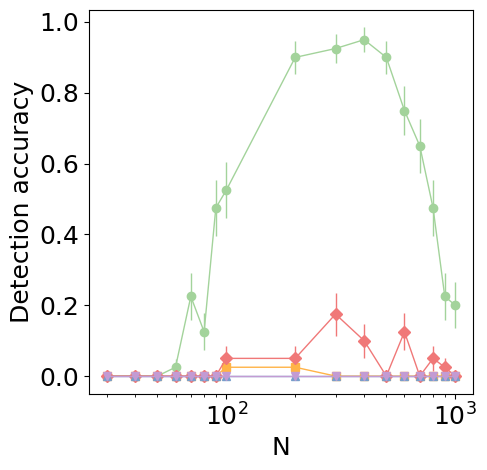

[0.0, 0.0, 0.0, 0.025, 0.225, 0.125, 0.475, 0.525, 0.9, 0.925, 0.95, 0.9, 0.75, 0.65, 0.475, 0.225, 0.2]


In [7]:
plt.errorbar(size,error_sampling_bms,error_sampling_bms_err,c='#a3d39b',marker='o',label='I-BMS',lw=1)
plt.errorbar(size,error_sampling_fit,error_sampling_fit_err,c='#ffb347',marker='s',label='RD-BMS',lw=1)
plt.errorbar(size,error_sampling_smooth,error_sampling_smooth_err,c='#f07878',marker='D',label='SD-BMS',lw=1)
plt.errorbar(size,error_sampling_sindy,error_sampling_sindy_err,c='#779ecb',marker='^',label='SINDY',lw=1)
plt.errorbar(size,error_sampling_sindymod,error_sampling_sindymod_err,c='#c39bd3',marker='v',label='R-SINDY',lw=1)

#plt.legend(loc='best',frameon=False)
plt.xlabel('N',fontsize=18)
plt.ylabel('Detection accuracy',fontsize=18)
plt.xscale('log')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax = plt.gca()
ax.set_box_aspect(1)
"""
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
#ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
#ax.minorticks_off()
ax.tick_params(which='minor')
"""
plt.tight_layout()
plt.show()
"""
plt.errorbar(list(range(100,1001,100)),error_sampling_bms,error_sampling_bms_bern_err,label='ode')
plt.errorbar(list(range(100,1001,100)),error_sampling_fit,error_sampling_fit_bern_err,label='fit')
plt.errorbar(list(range(100,1001,100)),error_sampling_smooth,error_sampling_smooth_bern_err,label='smooth')
plt.errorbar(list(range(100,1001,100)),error_sampling_sindy,error_sampling_sindy_bern_err,label='sindy')
plt.xscale('log')
plt.legend()
plt.xlabel('N')
plt.ylabel('% true expression')
plt.show()"""
print(error_sampling_bms)